In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import itertools

# 피처 선정 방법을 R2에서 MSE로 변경해보기기

In [2]:
%matplotlib inline

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']='Malgun Gothic'

In [3]:
df = pd.read_csv("../../DB/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,0.415669,0.353801,0.134385,0.071040,0.025105,0,0,0,0,1
2,강원_동해시,4818.0,강원,동해시,41141,90522,0.2689,0.6416,0.0426,0.0296,...,0.291131,0.333738,0.198045,0.133457,0.043630,1,0,0,0,0


In [4]:
year_columns = ['연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023']

# 연도 변수 생성
df['연도'] = df[year_columns].idxmax(axis=1).str.extract('(\d+)').astype(int)

# 기존 더미 변수 삭제
df = df.drop(columns=year_columns + ['log_혼합배출_후_재활용량'])
df.head(1)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,0.0281,3269,2968,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022


In [5]:
df.shape

(590, 20)

# data split

In [6]:
# 부산 2023
busan_2023 = df[(df['시도'] == '부산')&(df['연도'] == 2023)].reset_index(drop=True)
busan_2023.head(2)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,부산_강서구,11805.7,부산,강서구,62238,142396,0.1790,0.7894,0.0068,0.0159,0.0090,15487,16690,-1203,0.30575,0.267591,0.207005,0.176826,0.042828,2023
1,부산_금정구,24013.1,부산,금정구,105906,215590,0.1773,0.5656,0.0347,0.2080,0.0144,20637,25016,-4379,0.40046,0.295430,0.174782,0.104118,0.025210,2023


In [7]:
busan_2023.shape

(16, 20)

In [8]:
# 부산 2023 을 뺀 데이터 프레임
df_1 = df[~((df['시도'] == '부산')&(df['연도'] == 2023))].reset_index(drop=True)
df_1.head(2)

,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,비주거용주택비율,총전입,총전출,순이동,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,0.0281,3269,2968,301,0.386303,0.365099,0.144122,0.074742,0.029734,2022
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,0.0280,3262,2989,273,0.415669,0.353801,0.134385,0.071040,0.025105,2023


In [9]:
df_1.shape

(574, 20)

In [10]:
print(574* 0.8)
print(574* 0.2)

459.20000000000005
114.80000000000001


In [11]:
df_1[df_1['연도'] == 2023].shape

(114, 20)

In [12]:
df_1.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율', '연도'],
      dtype='object')

주민등록세대수, 총전출 은 변수(총인구수, 총전입입)간 상관관계가 너무 큼

In [13]:
rf_x_train = df_1[df_1['연도'] != 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동']]
rf_y_train = df_1[df_1['연도'] != 2023][['혼합배출_후_재활용량']]

rf_x_test = df_1[df_1['연도'] == 2023][['총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동']]
rf_y_test = df_1[df_1['연도'] == 2023][['혼합배출_후_재활용량']]

In [14]:
from itertools import combinations

# sort_values(by='RMSE') 를 수행해서 RMSE로 BEST 피처 조합찾기

In [23]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations(
    data: pd.DataFrame,           # 사용할 데이터프레임 x
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = rf_y_train['혼합배출_후_재활용량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            # X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            X_train = X_sub
            X_test = rf_x_test[selected_features]
            
            y_train = y_all
            y_test = rf_y_test['혼합배출_후_재활용량']
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'RMSE': rmse,                                       # RMSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최소 RMSE ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['RMSE'].idxmax()])
    
    return results_df_sorted

In [25]:
# feature 리스트 정의
my_selected_features_set1 = [
  '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=6
)

print("\n--- RMSE 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 13개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 100/286 완료 - R2: 0.0139, MSE: 270032951.9438, RMSE: 16432.6794
  > 조합 200/286 완료 - R2: 0.2481, MSE: 205896296.4558, RMSE: 14349.0870
  > 조합 286/286 완료 - R2: 0.0731, MSE: 253835805.5156, RMSE: 15932.2254

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/715 완료 - R2: 0.2247, MSE: 212301069.7648, RMSE: 14570.5549
  > 조합 200/715 완료 - R2: 0.2061, MSE: 217402040.4890, RMSE: 14744.5597
  > 조합 300/715 완료 - R2: 0.0486, MSE: 260530967.3031, RMSE: 16140.9717
  > 조합 400/715 완료 - R2: 0.0191, MSE: 268607747.2605, RMSE: 16389.2571
  > 조합 500/715 완료 - R2: 0.2514, MSE: 205004397.6964, RMSE: 14317.9746
  > 조합 600/715 완료 - R2: 0.0259, MSE: 266750863.2868, RMSE: 16332.5094
  > 조합 700/715 완료 - R2: 0.1782, MSE: 225050877.3693, RMSE: 15001.6958
  > 조합 715/715 완료 - R2: 0.0929, MSE: 248416421.7152, RMSE: 15761.2316

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/1287 완료 - R2: 0.4900, MSE: 139650336.6253, RMSE: 11817.3744
  > 조합 200/1287 완료 - R2: 0.1897, MSE:

,num_features,selected_features,R2,MSE,RMSE,feature_importances
0,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.546690,1.241359e+08,11141.629717,"[0.5216920440904979, 0.26551158307707384, 0.21..."
1,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.543929,1.248920e+08,11175.509779,"[0.45636391231257756, 0.22859889237583508, 0.1..."
2,4,"[총인구수, 단독주택비율, 다세대주택비율, 3인가구_비율]",0.527153,1.294860e+08,11379.191745,"[0.4611469425426695, 0.1507102537762848, 0.232..."


## 결과가 똑같음...!!!!

In [26]:
results_set1.head(7)

,num_features,selected_features,R2,MSE,RMSE,feature_importances
0,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.546690,1.241359e+08,11141.629717,"[0.5216920440904979, 0.26551158307707384, 0.21..."
1,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.543929,1.248920e+08,11175.509779,"[0.45636391231257756, 0.22859889237583508, 0.1..."
2,4,"[총인구수, 단독주택비율, 다세대주택비율, 3인가구_비율]",0.527153,1.294860e+08,11379.191745,"[0.4611469425426695, 0.1507102537762848, 0.232..."
3,5,"[총인구수, 단독주택비율, 다세대주택비율, 3인가구_비율, 총전입]",0.526555,1.296496e+08,11386.376916,"[0.40891077493381267, 0.14061680351222702, 0.1..."
4,5,"[총인구수, 다세대주택비율, 1인가구_비율, 3인가구_비율, 총전입]",0.525359,1.299772e+08,11400.754694,"[0.44243627377086087, 0.20987908036966632, 0.0..."
5,4,"[총인구수, 다세대주택비율, 1인가구_비율, 3인가구_비율]",0.523133,1.305868e+08,11427.459868,"[0.4928406451702031, 0.2452039172328325, 0.097..."
6,6,"[총인구수, 다세대주택비율, 2인가구_비율, 3인가구_비율, 5인이상가구_비율, 총전입]",0.519892,1.314742e+08,11466.219529,"[0.3669294001440328, 0.17662937172392568, 0.19..."


In [29]:
def plot_model_performance_and_importance(results_df: pd.DataFrame):
    if results_df.empty:
        print("시각화를 할 수 없음. 데이터프레임이 없다..!")
        return

    # num_feature별로 가장 높은 R2값 정렬
    plot_data = results_df.loc[results_df.groupby('num_features')['R2'].idxmax()].reset_index(drop=True)

    # feature의 수에 상관없이 R2가 가장 높은 건 데이터프레임의 0번째 행에 있음
    best_model_row = results_df.iloc[0]
    best_r2_score = best_model_row['R2']
    best_features_combo = best_model_row['selected_features']
    best_importances = best_model_row['feature_importances']
    best_num_features = best_model_row['num_features']

    # 베스트 모델의 feature importance 데이터프레임 만들기
    best_importance_df = pd.DataFrame({
        'feature': best_features_combo,
        'importance': best_importances
    }).sort_values(by='importance', ascending=False)

    # 그래프의 크기 설정
    height_ratio_plot1 = 1.0
    height_ratio_plot2 = max(0.5, len(best_features_combo) * 0.1)

    base_figure_height = 8 
    total_figure_height_ratio = height_ratio_plot1 + height_ratio_plot2
    calculated_height = base_figure_height * (total_figure_height_ratio / 1.5)

    fig, axes = plt.subplots(2, 1, figsize=(10, calculated_height),
                             gridspec_kw={'height_ratios': [height_ratio_plot1, height_ratio_plot2]})
    fig.suptitle('모델 성능 및 피처 중요도 분석', fontsize=16, y=1.02)

    # --- Plot 1: feature의 개수에 따른 R2와 MSE ---
    ax1 = axes[0]
    ax1_2 = ax1.twinx()

    sns.lineplot(x='num_features', y='R2', data=plot_data, marker='o', color='green', ax=ax1)
    sns.lineplot(x='num_features', y='MSE', data=plot_data, marker='s', color='orange', ax=ax1_2)

    ax1.set_xlabel("Number of Features")
    ax1.set_ylabel("R2 Score", color='green')
    ax1_2.set_ylabel("Mean Squared Error (MSE)", color='orange')
    ax1.tick_params(axis='y', labelcolor='green')
    ax1_2.tick_params(axis='y', labelcolor='orange')
    ax1.set_title("R2 Score and MSE by Number of Features")
    ax1.grid(True, linestyle='--', alpha=0.3)

    lines = [
        plt.Line2D([0], [0], color='green', marker='o', label='R2 Score'),
        plt.Line2D([0], [0], color='orange', marker='s', label='MSE')
    ]
    ax1.legend(handles=lines, loc='upper right')

    # --- Plot 2: 베스트 모델의 Feature Importance ---
    ax3 = axes[1]
    sns.barplot(data=best_importance_df, x='importance', y='feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Feature Importance for Best Model (Top {best_num_features} Features, R²={best_r2_score:.4f})')
    ax3.set_xlabel('Importance')
    ax3.set_ylabel('Feature')

    plt.xticks(plot_data['num_features'])
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])

C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\2458305383.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_importance_df, x='importance', y='feature', palette='viridis', ax=ax3)


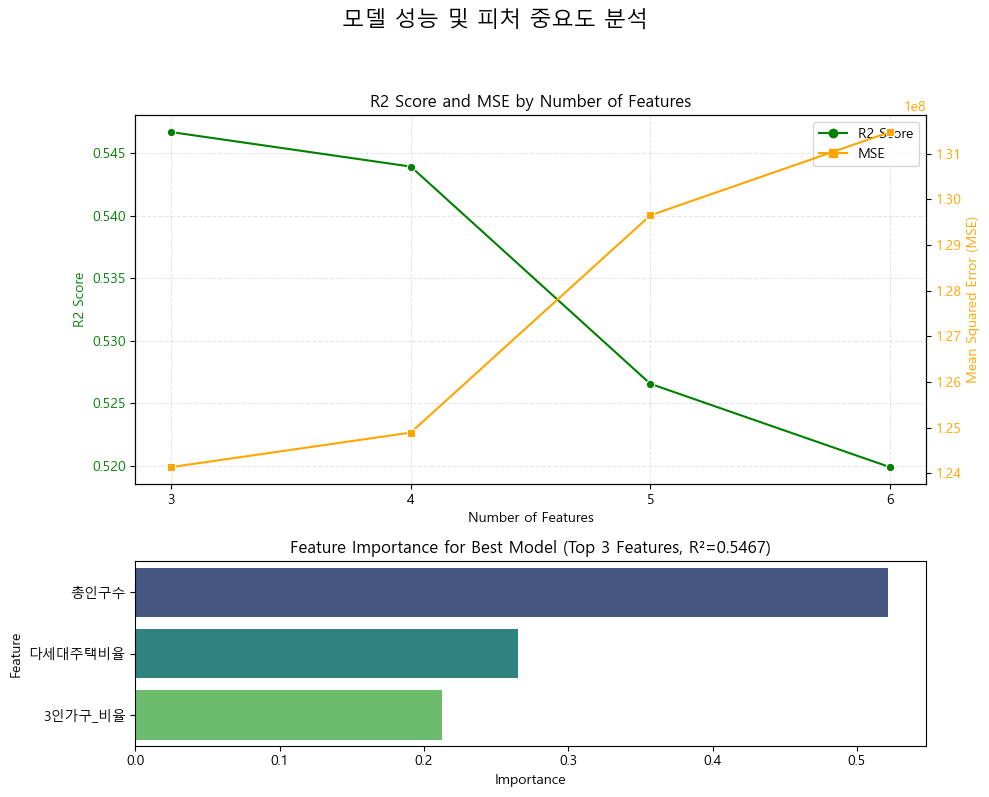

In [30]:
plot_model_performance_and_importance(results_set1)

# random_state=100 바꿔보기

In [32]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations100(
    data: pd.DataFrame,           # 사용할 데이터프레임 x
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = rf_y_train['혼합배출_후_재활용량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            # X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            X_train = X_sub
            X_test = rf_x_test[selected_features]
            
            y_train = y_all
            y_test = rf_y_test['혼합배출_후_재활용량']
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=100)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'RMSE': rmse,                                       # RMSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최소 RMSE ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['RMSE'].idxmax()])
    
    return results_df_sorted

In [33]:
# feature 리스트 정의
my_selected_features_set1 = [
  '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', 
       '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율','총전입', '순이동'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations100(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=4
)

print("\n--- RMSE 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 13개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 100/286 완료 - R2: 0.0266, MSE: 266553764.5446, RMSE: 16326.4743
  > 조합 200/286 완료 - R2: 0.2330, MSE: 210038961.8757, RMSE: 14492.7210
  > 조합 286/286 완료 - R2: 0.0634, MSE: 256490362.3301, RMSE: 16015.3165

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/715 완료 - R2: 0.2102, MSE: 216290597.2479, RMSE: 14706.8215
  > 조합 200/715 완료 - R2: 0.1983, MSE: 219550498.4006, RMSE: 14817.2365
  > 조합 300/715 완료 - R2: 0.0534, MSE: 259212283.9695, RMSE: 16100.0709
  > 조합 400/715 완료 - R2: 0.0368, MSE: 263757333.3945, RMSE: 16240.6075
  > 조합 500/715 완료 - R2: 0.2550, MSE: 204017743.0531, RMSE: 14283.4780
  > 조합 600/715 완료 - R2: 0.0205, MSE: 268240729.0742, RMSE: 16378.0563
  > 조합 700/715 완료 - R2: 0.1948, MSE: 220488289.3790, RMSE: 14848.8481
  > 조합 715/715 완료 - R2: 0.1067, MSE: 244626753.7025, RMSE: 15640.5484

--- 탐색 완료 ---

--- 각 피처 개수별 최소 RMSE ---
     num_features                 selected_features        R2           MSE  \
200           

,num_features,selected_features,R2,MSE,RMSE,feature_importances
0,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.542460,1.252943e+08,11193.491675,"[0.46449242431581883, 0.222849241184304, 0.191..."
1,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.537737,1.265875e+08,11251.112199,"[0.5213708698127687, 0.2608367493610453, 0.217..."
2,4,"[총인구수, 다세대주택비율, 3인가구_비율, 5인이상가구_비율]",0.515284,1.327360e+08,11521.112522,"[0.4640302296141807, 0.22797342386314162, 0.15..."


In [34]:
results_set1.head(7) 

,num_features,selected_features,R2,MSE,RMSE,feature_importances
0,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.542460,1.252943e+08,11193.491675,"[0.46449242431581883, 0.222849241184304, 0.191..."
1,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.537737,1.265875e+08,11251.112199,"[0.5213708698127687, 0.2608367493610453, 0.217..."
2,4,"[총인구수, 다세대주택비율, 3인가구_비율, 5인이상가구_비율]",0.515284,1.327360e+08,11521.112522,"[0.4640302296141807, 0.22797342386314162, 0.15..."
3,4,"[총인구수, 단독주택비율, 다세대주택비율, 3인가구_비율]",0.511611,1.337421e+08,11564.690742,"[0.4611910123706847, 0.1592277528993472, 0.216..."
4,4,"[총인구수, 다세대주택비율, 2인가구_비율, 3인가구_비율]",0.496917,1.377657e+08,11737.362707,"[0.42929736554140363, 0.21052086957920407, 0.2..."
5,4,"[총인구수, 다세대주택비율, 1인가구_비율, 3인가구_비율]",0.493406,1.387274e+08,11778.257742,"[0.4926346351629156, 0.23756427736611205, 0.10..."
6,4,"[총인구수, 연립주택비율, 다세대주택비율, 3인가구_비율]",0.490614,1.394919e+08,11810.670188,"[0.4359837648614028, 0.1880299964379282, 0.205..."


In [36]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations50(
    data: pd.DataFrame,           # 사용할 데이터프레임 x
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = rf_y_train['혼합배출_후_재활용량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            # X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            X_train = X_sub
            X_test = rf_x_test[selected_features]
            
            y_train = y_all
            y_test = rf_y_test['혼합배출_후_재활용량']
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=50)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'RMSE': rmse,                                       # RMSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최소 RMSE ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['RMSE'].idxmax()])
    
    return results_df_sorted

In [37]:
# feature 리스트 정의
my_selected_features_set1 = [
  '총인구수','다세대주택비율','3인가구_비율', '총전입', '단독주택비율','1인가구_비율','2인가구_비율','5인이상가구_비율'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations50(
    data=rf_x_train,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=7
)

print("\n--- RMSE 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 8개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.0214, MSE: 267989526.1083, RMSE: 16370.3856

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 70/70 완료 - R2: 0.2094, MSE: 216505346.9106, RMSE: 14714.1207

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.4191, MSE: 159062597.4221, RMSE: 12612.0021

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 28/28 완료 - R2: 0.4387, MSE: 153721567.2489, RMSE: 12398.4502

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 8/8 완료 - R2: 0.4792, MSE: 142604346.6010, RMSE: 11941.7062

--- 탐색 완료 ---

--- 각 피처 개수별 최소 RMSE ---
     num_features                                  selected_features  \
55              3                      [1인가구_비율, 2인가구_비율, 5인이상가구_비율]   
110             4             [다세대주택비율, 1인가구_비율, 2인가구_비율, 5인이상가구_비율]   
180             5     [3인가구_비율, 단독주택비율, 1인가구_비율, 2인가구_비율, 5인이상가구_비율]   
207             6  [다세대주택비율, 3인가구_비율, 단독주택비율, 1인가구_비율, 2인가구_비율, 5...   
215             7  [총인구수, 다세대주택비율, 총전입, 단독주택비율, 1인가구_비율, 2인가구_비율,...   

           R2  

,num_features,selected_features,R2,MSE,RMSE,feature_importances
0,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.530256,1.286362e+08,11341.788960,"[0.5199883186794261, 0.2664527554353481, 0.213..."
1,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.524646,1.301723e+08,11409.307351,"[0.45826112180506307, 0.22460372280462493, 0.1..."
2,7,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입, 단독주택비율, 2인가구_비율,...",0.514964,1.328239e+08,11524.924185,"[0.3495435421690548, 0.15454830342036807, 0.09..."


In [38]:
results_set1.head(7)

,num_features,selected_features,R2,MSE,RMSE,feature_importances
0,3,"[총인구수, 다세대주택비율, 3인가구_비율]",0.530256,1.286362e+08,11341.788960,"[0.5199883186794261, 0.2664527554353481, 0.213..."
1,4,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입]",0.524646,1.301723e+08,11409.307351,"[0.45826112180506307, 0.22460372280462493, 0.1..."
2,7,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입, 단독주택비율, 2인가구_비율,...",0.514964,1.328239e+08,11524.924185,"[0.3495435421690548, 0.15454830342036807, 0.09..."
3,4,"[총인구수, 다세대주택비율, 3인가구_비율, 1인가구_비율]",0.511992,1.336377e+08,11560.179172,"[0.4885933652439533, 0.24198927999904102, 0.17..."
4,6,"[총인구수, 다세대주택비율, 3인가구_비율, 단독주택비율, 2인가구_비율, 5인이상...",0.510020,1.341776e+08,11583.506495,"[0.3924307026654411, 0.1729966860390267, 0.103..."
5,5,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입, 1인가구_비율]",0.509382,1.343524e+08,11591.049912,"[0.4437288690888409, 0.20566091962909125, 0.14..."
6,6,"[총인구수, 다세대주택비율, 3인가구_비율, 총전입, 단독주택비율, 2인가구_비율]",0.508842,1.345003e+08,11597.426303,"[0.35707070956389836, 0.16172862018826875, 0.1..."


# 대안
 계속 [총인구수, 다세대주택비율, 3인가구_비율]로 똑같다 어떻게 해야할까!
 1. 최대한 튜닝한다 -> R2가 작아지고 MSE가 커짐
 2. R2가 크고 MSE가 작은 초기 상태로 그대로 간다
 3. TEST결과 일정 R2, MSE가 넘으면 부산 MSE가 가장 작은 피처 랜덤포레스트로 한다.  
  
- 참고로 random_state=42일때,  [총인구수, 다세대주택비율, 3인가구_비율] R2, MSE이 가장 좋음

## 3. TEST결과 일정 R2, MSE가 넘으면 부산 MSE가 가장 작은 피처 랜덤포레스트로 한다.  해보기❗

first: '총인구수', '다세대주택비율', '3인가구_비율'

In [45]:
first_x_train = rf_x_train[['총인구수', '다세대주택비율', '3인가구_비율']]
first_x_test = rf_x_test[['총인구수', '다세대주택비율', '3인가구_비율']]

In [46]:
first_model = RandomForestRegressor(random_state=42)
first_model.fit(first_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
first_predictions = first_model.predict(first_x_test)
mse = mean_squared_error(rf_y_test, first_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, first_predictions)
mae = mean_absolute_error(rf_y_test, first_predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

predict_list = {}
predict_list["first"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}

MSE: 127905910.1162, RMSE: 11309.5495, R^2: 0.5329, MAE: 6221.9761


In [48]:
x_busan = busan_2023[['행정구역','연도', '총인구수', '다세대주택비율',  '3인가구_비율']].set_index(['행정구역','연도'])
predicted_busan = first_model.predict(x_busan)
predicted_y = busan_2023[['행정구역','연도','총인구수','혼합배출_후_재활용량']]
predicted_y['first'] = predicted_busan

C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\500582745.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['first'] = predicted_busan


In [49]:
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)

busan_list = {}
busan_list["first"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 62689390.3990, RMSE: 7917.6632, R^2: 0.0632, MAE: 6467.3609


second : [총인구수, 다세대주택비율, 3인가구_비율, 총전입]

In [54]:
second_x_train = rf_x_train[['총인구수', '다세대주택비율', '3인가구_비율', '총전입']]
second_x_test = rf_x_test[['총인구수', '다세대주택비율', '3인가구_비율', '총전입']]

In [55]:
second_model = RandomForestRegressor(random_state=42)
second_model.fit(second_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
second_predictions = second_model.predict(second_x_test)
mse = mean_squared_error(rf_y_test, second_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, second_predictions)
mae = mean_absolute_error(rf_y_test, second_predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")


predict_list["second"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}

MSE: 126484539.2118, RMSE: 11246.5345, R^2: 0.5381, MAE: 6277.3097


In [59]:
x_busan = busan_2023[['행정구역','연도', '총인구수', '다세대주택비율',  '3인가구_비율', '총전입']].set_index(['행정구역','연도'])
predicted_busan = second_model.predict(x_busan)
predicted_y['second'] = predicted_busan

C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\1084862505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['second'] = predicted_busan


In [60]:
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)

busan_list["second"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 66712170.8646, RMSE: 8167.7519, R^2: 0.0031, MAE: 6777.6270


third : 	[총인구수, 단독주택비율, 다세대주택비율, 3인가구_비율]

In [64]:
third_x_train = rf_x_train[['총인구수', '다세대주택비율', '3인가구_비율', '단독주택비율']]
third_x_test = rf_x_test[['총인구수', '다세대주택비율', '3인가구_비율', '단독주택비율']]

In [65]:
third_model = RandomForestRegressor(random_state=42)
third_model.fit(third_x_train, rf_y_train)

c:\workspace\busan\.venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
third_predictions = third_model.predict(third_x_test)
mse = mean_squared_error(rf_y_test, third_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(rf_y_test, third_predictions)
mae = mean_absolute_error(rf_y_test, third_predictions)
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")


predict_list["third"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}

MSE: 123968346.3635, RMSE: 11134.1073, R^2: 0.5473, MAE: 5886.8211


In [68]:
x_busan = busan_2023[['행정구역','연도', '총인구수', '다세대주택비율', '3인가구_비율', '단독주택비율']].set_index(['행정구역','연도'])
predicted_busan = third_model.predict(x_busan)
predicted_y['third'] = predicted_busan

C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\380473206.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_y['third'] = predicted_busan


In [69]:
mse = mean_squared_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)
rmse = np.sqrt(mse)
r2 = r2_score(predicted_y['혼합배출_후_재활용량'], predicted_busan)
mae = mean_absolute_error(predicted_y['혼합배출_후_재활용량'], predicted_busan)

busan_list["third"] = {
    'MSE': mse,
    'RMSE': rmse,
    'R^2': r2,
    'MAE': mae
}
print(f"MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}, MAE: {mae:.4f}")

MSE: 68851316.3834, RMSE: 8297.6693, R^2: -0.0288, MAE: 6834.3548


In [70]:
busan_list

{'first': {'MSE': 62689390.399004646,
  'RMSE': np.float64(7917.663190550899),
  'R^2': 0.06324374263693655,
  'MAE': 6467.360874999999},
 'second': {'MSE': 66712170.86464327,
  'RMSE': np.float64(8167.7518855951585),
  'R^2': 0.003132059476515958,
  'MAE': 6777.627},
 'third': {'MSE': 68851316.38341592,
  'RMSE': np.float64(8297.669334422524),
  'R^2': -0.028832806306454906,
  'MAE': 6834.354812499999}}

# 결론
first가 busan도 제일 mse적게 예측함

In [81]:
busan_first = predicted_y[['행정구역', '연도',	'총인구수',	'혼합배출_후_재활용량',	'first']]

In [82]:
busan_first['오차(실제값기준)'] = busan_first['혼합배출_후_재활용량'] - busan_first['first']

C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\3688987929.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  busan_first['오차(실제값기준)'] = busan_first['혼합배출_후_재활용량'] - busan_first['first']


C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\3682020021.py:13: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()


c:\workspace\busan\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
c:\workspace\busan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


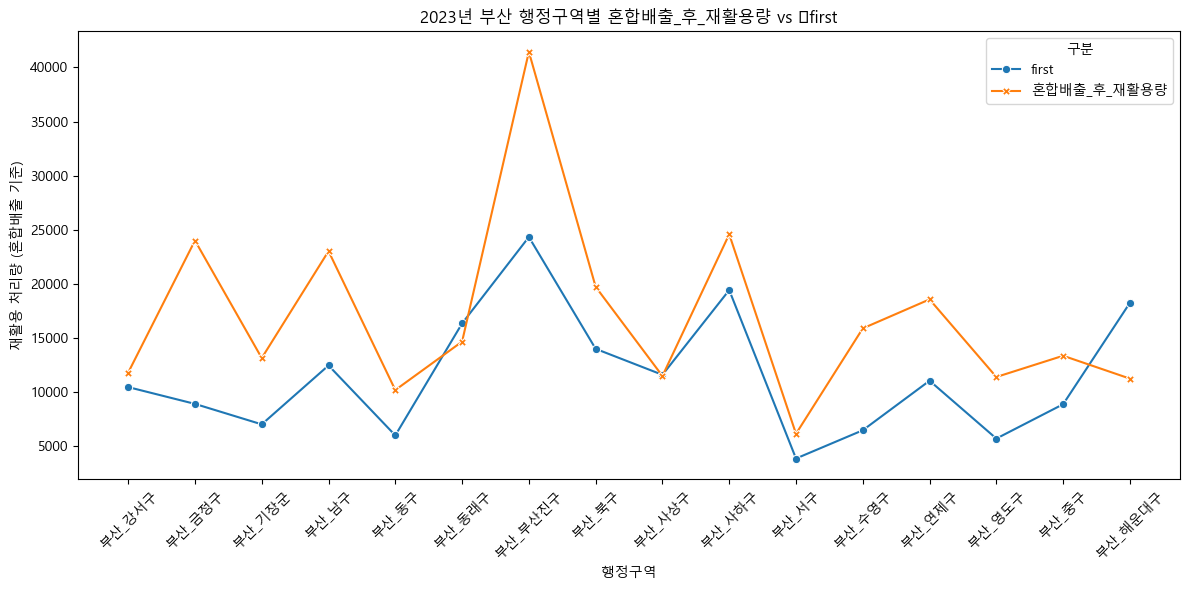

In [83]:
# 시군구별 예측값/실제값 형태 변환
df_plot = busan_first[['행정구역', 'first', '혼합배출_후_재활용량']].melt(id_vars='행정구역', var_name='구분', value_name='값')

# 시군구 이름 기준 정렬
order = busan_first.sort_values(by='혼합배출_후_재활용량', ascending=False)['행정구역']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='행정구역', y='값', hue='구분', style='구분', markers=True, dashes=False, sort=False)
plt.xticks(rotation=45)
plt.title('2023년 부산 행정구역별 혼합배출_후_재활용량 vs 	first')
plt.ylabel('재활용 처리량 (혼합배출 기준)')
plt.xlabel('행정구역')
plt.tight_layout()
plt.legend(title='구분')

In [84]:
busan_first

,행정구역,연도,총인구수,혼합배출_후_재활용량,first,오차(실제값기준)
0,부산_강서구,2023,142396,11805.7,10470.784,1334.916
1,부산_금정구,2023,215590,24013.1,8918.680,15094.420
2,부산_기장군,2023,178729,13154.8,7028.226,6126.574
3,부산_남구,2023,254185,23032.7,12471.135,10561.565
4,부산_동구,2023,87792,10200.1,6007.213,4192.887
5,부산_동래구,2023,270815,14674.0,16353.151,-1679.151
6,부산_부산진구,2023,359508,41448.2,24339.463,17108.737
7,부산_북구,2023,273596,19735.6,14006.110,5729.490
8,부산_사상구,2023,202932,11497.8,11605.771,-107.971
9,부산_사하구,2023,297831,24589.7,19433.512,5156.188


C:\Users\nammi\AppData\Local\Temp\ipykernel_22464\3655287378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')


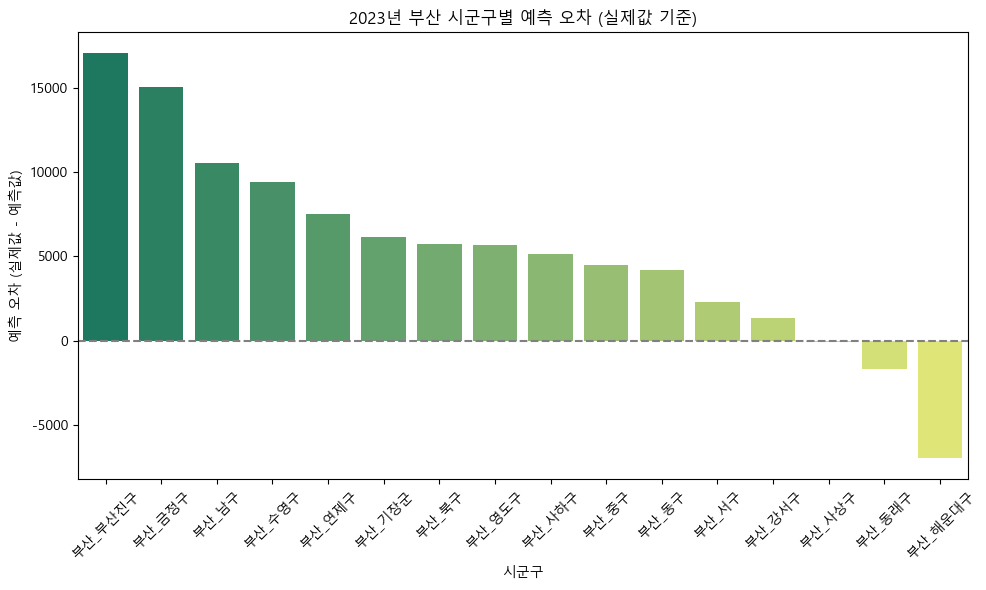

In [85]:
plt.figure(figsize=(10, 6))
df_sorted_heatmap = busan_first.sort_values(by='오차(실제값기준)', ascending=False)
sns.barplot(data=df_sorted_heatmap, x='행정구역', y='오차(실제값기준)', palette='summer')
plt.xticks(rotation=45)
plt.title('2023년 부산 시군구별 예측 오차 (실제값 기준)')
plt.ylabel('예측 오차 (실제값 - 예측값)')
plt.xlabel('시군구')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()

In [86]:
busan_first = predicted_y[['행정구역', '연도',	'총인구수',	'혼합배출_후_재활용량',	'first']]
busan_first

,행정구역,연도,총인구수,혼합배출_후_재활용량,first
0,부산_강서구,2023,142396,11805.7,10470.784
1,부산_금정구,2023,215590,24013.1,8918.680
2,부산_기장군,2023,178729,13154.8,7028.226
3,부산_남구,2023,254185,23032.7,12471.135
4,부산_동구,2023,87792,10200.1,6007.213
5,부산_동래구,2023,270815,14674.0,16353.151
6,부산_부산진구,2023,359508,41448.2,24339.463
7,부산_북구,2023,273596,19735.6,14006.110
8,부산_사상구,2023,202932,11497.8,11605.771
9,부산_사하구,2023,297831,24589.7,19433.512


In [87]:
busan_first.to_csv('../../DB/보리_부산예측2023.csv', encoding='CP949', index=False)

In [89]:
predicted_y.to_csv('../../DB/보리_전부_부산예측2023.csv', encoding='CP949', index=False)